# Linear regression in Python

We are going to do linear regression with one familiar dataset, the Toluca dataset


In [2]:
# Importing numpy and pandas libraries to read the data

# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Import the numpy and pandas package
import numpy as np
import pandas as pd

# loading the dataset, careful about the path
toluca = pd.read_csv("toluca.csv")
toluca



,hours,parts
0,80,399
1,30,121
2,50,221
3,90,376
4,70,361
5,60,224
6,120,546
7,80,352
8,100,353
9,50,157


Let’s perform some tasks to understand the data like shape, info, and describe.

In [3]:
# Shape of our dataset
toluca.shape

# Info our dataset
toluca.info()

# Describe our dataset
toluca.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   hours   25 non-null     int64
 1   parts   25 non-null     int64
dtypes: int64(2)
memory usage: 528.0 bytes


,hours,parts
count,25.000000,25.000000
mean,70.000000,312.280000
std,28.722813,113.137645
min,20.000000,113.000000
25%,50.000000,224.000000
50%,70.000000,342.000000
75%,90.000000,389.000000
max,120.000000,546.000000


# Visualizing the data

Let’s now visualize the data using the matplolib and seaborn library. We’ll make a pairplot of all the columns and see which columns are the most correlated to Sales.


Text(0, 0.5, 'Parts')

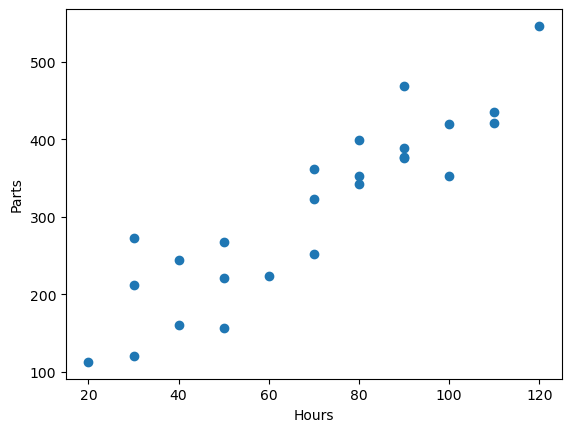

In [5]:
# Import matplotlib libraries to visualize the data
import matplotlib.pyplot as plt 


plt.plot(toluca.hours,toluca.parts,'o')
plt.xlabel('Hours')
plt.ylabel('Parts')


# Building and training the model

Using the statsmodel and sklearn packages, we can build a simple linear regression model.

First, we’ll build the model using the statsmodel package. To do that, we need to import the statsmodel.api library to perform linear regression.

By default, the statsmodel library fits a line that passes through the origin. But simple linear regression needs an intercept as well. So, to have it, we need to add the add_constant attribute manually.


In [7]:
# Importing Statsmodels.api library from Stamodel package
import statsmodels.api as sm

# Adding a constant to get an intercept
toluca_hours_sm = sm.add_constant(toluca.hours)

# Fitting the resgression line using 'OLS'
lr = sm.OLS(toluca.parts, toluca_hours_sm).fit()

# Printing the parameters
lr.params



const    62.365859
hours     3.570202
dtype: float64

Now let's get the model summary

In [8]:

# Performing a summary to list out all the different parameters of the regression line fitted
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  parts   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     105.9
Date:                Tue, 24 Jan 2023   Prob (F-statistic):           4.45e-10
Time:                        12:09:59   Log-Likelihood:                -131.64
No. Observations:                  25   AIC:                             267.3
Df Residuals:                      23   BIC:                             269.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         62.3659     26.177      2.382      0.026       8.214     116.518
hours          3.5702      0.347     10.290      0.000       2.852       4.288
==============================================================================
Omnibus:                        0.608   Durbin-Watson:                   1.432
Prob(Omnibus):                  0.738   Jarque-Bera (JB):                0.684
Skew:                           0.298   Prob(JB):                        0.710
Kurtosis:                       2.450   Cond. No.                         202.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Diagnostics

Now let's see how well our model performs on the data.



Text(0, 0.5, 'Parts')

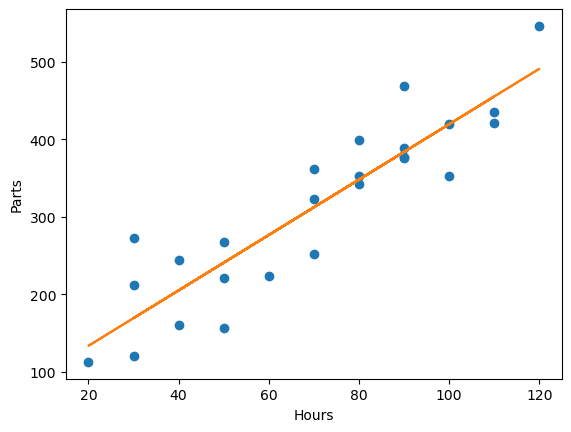

In [9]:
fitted_values = lr.predict(toluca_hours_sm)

plt.plot(toluca.hours,toluca.parts,'o')
plt.plot(toluca.hours,fitted_values)

plt.xlabel('Hours')
plt.ylabel('Parts')




Let's have a look at the residuals



Text(0, 0.5, 'Parts')

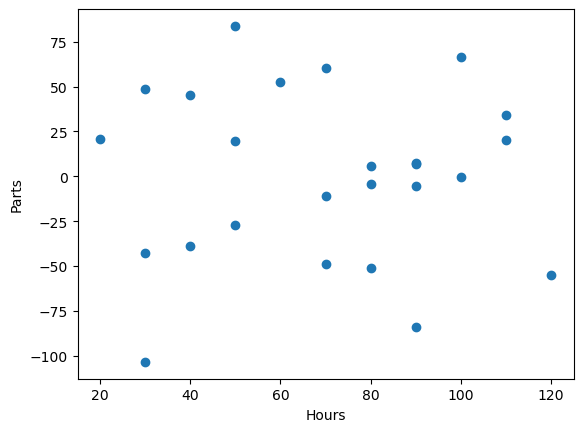

In [10]:
res=fitted_values-toluca.parts

plt.plot(toluca.hours,res,'o')

plt.xlabel('Hours')
plt.ylabel('Parts')


# (Multiple) linear regression

The proposed code works great for simple linear regression, but for multiple linear regression there are other ways

In [11]:
# loading the dataset, careful about the path
dwaine = pd.read_csv("dwaine.csv")
dwaine

x = dwaine[['targtpop','dispoinc']]
x = sm.add_constant(x)

model = sm.OLS(dwaine.sales, x).fit()
predictions = model.predict(x) 
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     99.10
Date:                Tue, 24 Jan 2023   Prob (F-statistic):           1.92e-10
Time:                        12:11:05   Log-Likelihood:                -78.549
No. Observations:                  21   AIC:                             163.1
Df Residuals:                      18   BIC:                             166.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -68.8571     60.017     -1.147      0.2